<a href="https://colab.research.google.com/github/taehi5/Esaa_YB/blob/3%EC%A3%BC%EC%B0%A8---%EA%B3%BC%EC%A0%9C/ESAA_YB_Week3_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 12-1 datetime 오브젝트

datetime 라이브러리: 날짜와 시간을 처리하는 등 다양한 기능을 제공
- date 오브젝트 : 날짜 처리
- time 오브젝트 : 시간 처리
- datetime 오브젝트 : 날짜와 시간 모두 처리

In [1]:
# 라이브러리 생성
from datetime import datetime

In [2]:
# now, today : 현재 시간 출력
now1 = datetime.now()
print(now1)

2026-09-21 01:02:00.535329


In [3]:
now2 = datetime.today()
print(now2)

2026-09-21 01:02:00.544516


In [5]:
# 입력한 시간을 바탕으로 datetime 생성
t1 = datetime.now()
t2 = datetime(1970,1,1)
t3 = datetime(1970,12,12,13,24,34)

print(t1)
print(t2)
print(t3)

2026-09-21 01:03:44.677596
1970-01-01 00:00:00
1970-12-12 13:24:34


In [7]:
# 시간 계산
diff1 = t1 - t2

print(diff1)
print(type(diff1))

20717 days, 1:03:44.677596
<class 'datetime.timedelta'>


In [8]:
diff2 = t2 - t1

print(diff2)
print(type(diff2))

-20718 days, 22:56:15.322404
<class 'datetime.timedelta'>


## to_datetime 메서드
시계열 데이터를 문자열로 저장해야할 때 사용

In [12]:
# 문자열 -> datetime으로
import pandas as pd
import os

ebola = pd.read_csv('/content/country_timeseries.csv')

In [13]:
print(ebola.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 122 non-null    object 
 1   Day                  122 non-null    int64  
 2   Cases_Guinea         93 non-null     float64
 3   Cases_Liberia        83 non-null     float64
 4   Cases_SierraLeone    87 non-null     float64
 5   Cases_Nigeria        38 non-null     float64
 6   Cases_Senegal        25 non-null     float64
 7   Cases_UnitedStates   18 non-null     float64
 8   Cases_Spain          16 non-null     float64
 9   Cases_Mali           12 non-null     float64
 10  Deaths_Guinea        92 non-null     float64
 11  Deaths_Liberia       81 non-null     float64
 12  Deaths_SierraLeone   87 non-null     float64
 13  Deaths_Nigeria       38 non-null     float64
 14  Deaths_Senegal       22 non-null     float64
 15  Deaths_UnitedStates  18 non-null     flo

In [14]:
#to_datetime을 이용해 date 열의 자료형 -> datetime 오브젝트로 변경
ebola['date_dt'] = pd.to_datetime(ebola['Date'])
print(ebola.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    object        
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liberia        83 non-null     float64       
 4   Cases_SierraLeone    87 non-null     float64       
 5   Cases_Nigeria        38 non-null     float64       
 6   Cases_Senegal        25 non-null     float64       
 7   Cases_UnitedStates   18 non-null     float64       
 8   Cases_Spain          16 non-null     float64       
 9   Cases_Mali           12 non-null     float64       
 10  Deaths_Guinea        92 non-null     float64       
 11  Deaths_Liberia       81 non-null     float64       
 12  Deaths_SierraLeone   87 non-null     float64       
 13  Deaths_Nigeria       38 non-null   

In [15]:
""" 시간 형식 지정자& 기호를 조합해 format 인자 전달
     => 그 형식에 맞는 datetime 오브젝트 얻음 """
test_df1 = pd.DataFrame({'order_day':['01/01/15','02/01/15','03/01/15']})

test_df1['date_dt1'] = pd.to_datetime(test_df1['order_day'], format='%d/%m/%y')
test_df1['date_dt2'] = pd.to_datetime(test_df1['order_day'], format='%m/%d/%y')
test_df1['date_dt3'] = pd.to_datetime(test_df1['order_day'], format='%y/%m/%d')

print(test_df1)

  order_day   date_dt1   date_dt2   date_dt3
0  01/01/15 2015-01-01 2015-01-01 2001-01-15
1  02/01/15 2015-01-02 2015-02-01 2002-01-15
2  03/01/15 2015-01-03 2015-03-01 2003-01-15


In [18]:
test_df2 = pd.DataFrame({'order_day':['01-01-15', '02-01-15', '03-01-15']})
test_df2['date_dt'] = pd.to_datetime(test_df2['order_day'], format='%d-%m-%y')
print(test_df2)

  order_day    date_dt
0  01-01-15 2015-01-01
1  02-01-15 2015-01-02
2  03-01-15 2015-01-03


## 시간 형식 지정자
- %a : 요일 출력
- %A : 요일 출력(긴 이름)
- %w : 요일 출력(숫자, 0부터 일요일)
- %d : 날짜 출력(2자리로 표시)
- %b : 월 출력
- %B : 월 출력(긴 이름)
- %m : 월 출력(숫자)
- %y : 년 출력(2자리로 표시)
- %Y : 년 출력(4자리로 표시)
- %H : 시간 출력(24시간)
- %I : 시간 출력(12시간)
- %p : AM 또는 PM 출력
- %M : 분 출력(2자리로 표시)
- %S : 초 출력(2자리로 표시)
- %f : 마이크로초 출력
- %z : UTC 차이 출력(+HHMM이나 -HHMM형태)
- %j : 올해의 지난 일 수 출력(1일, 2일, ...)
- %U : 올해의 지난 주 수 출력(1주, 2주, ...)
- %c : 날짜와 시간 출력
- %x : 날짜 출력
- %X : 시간 출력
- %G : 년 출력(ISO 8601 형식)
- %u : 요일 출력(ISO 8601 형식)
- %V : 올해의 지난 주 수 출력(ISO 8601 형식)

### 시계열 데이터 구분 추출
strftime 메서드 + 시간 형식 지정자 이용

In [19]:
now = datetime.now()
print(now)

2026-09-21 01:36:31.104872


In [20]:
nowDate = now.strftime('%Y-%m-%d')
print(nowDate)

2026-09-21


In [21]:
nowTime = now.strftime('%H:%M:%S')
print(nowTime)

01:36:31


In [22]:
nowDatetime = now.strftime('%Y-%m-%d %H:%M:%S')
print(nowDatetime)

2026-09-21 01:36:31


## read_csv 메서드
datetime 오브젝트로 변환하려는 열을 지정, 데이터를 불러오는 것이 더 간단

In [23]:
# parse_dates 인자에 datetime 오브젝트로 변환하고자 하는 열의 이름을 전달
ebola1 = pd.read_csv('/content/country_timeseries.csv')
print(ebola1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 122 non-null    object 
 1   Day                  122 non-null    int64  
 2   Cases_Guinea         93 non-null     float64
 3   Cases_Liberia        83 non-null     float64
 4   Cases_SierraLeone    87 non-null     float64
 5   Cases_Nigeria        38 non-null     float64
 6   Cases_Senegal        25 non-null     float64
 7   Cases_UnitedStates   18 non-null     float64
 8   Cases_Spain          16 non-null     float64
 9   Cases_Mali           12 non-null     float64
 10  Deaths_Guinea        92 non-null     float64
 11  Deaths_Liberia       81 non-null     float64
 12  Deaths_SierraLeone   87 non-null     float64
 13  Deaths_Nigeria       38 non-null     float64
 14  Deaths_Senegal       22 non-null     float64
 15  Deaths_UnitedStates  18 non-null     flo

## datetime 오브젝트에서 날짜 정보 추출
datetime 오브젝트에는 년, 월, 일이 따로 저장된 속성이 준비됨

In [24]:
# 문자열로 저장된 날짜를 시리즈에 담아 datetime 오브젝트로 변환
date_series = pd.Series(['2018-05-16','2018-05-17','2018-05-18'])
d1 = pd.to_datetime(date_series)
print(d1)

0   2018-05-16
1   2018-05-17
2   2018-05-18
dtype: datetime64[ns]


In [25]:
# year,month,dat 속성 이용해 년, 월, 일 정보 추출
print(d1[0].year)

2018


In [26]:
print(d1[0].month)

5


In [27]:
print(d1[0].day)

16


## dt 접근자 사용
dt 접근자를 이용해 datetime 속성이나 메서드 사용

In [28]:
# date 열을 datetime 오브젝트로 변환 후 새로운 열로 추가
ebola = pd.read_csv('/content/country_timeseries.csv')
ebola['date_dt'] = pd.to_datetime(ebola['Date'])

In [29]:
# dt 접근자 사용 X 인자 추출
print(ebola[['Date','date_dt']].head())

         Date    date_dt
0    1/5/2015 2015-01-05
1    1/4/2015 2015-01-04
2    1/3/2015 2015-01-03
3    1/2/2015 2015-01-02
4  12/31/2014 2014-12-31


In [30]:
print(ebola['date_dt'][3].year)

2015


In [31]:
print(ebola['date_dt'][3].month)

1


In [33]:
print(ebola['date_dt'][3].day)

2


In [34]:
# dt 접근자로 추출
ebola['year'] = ebola['date_dt'].dt.year
print(ebola[['Date','date_dt','year']].head())

         Date    date_dt  year
0    1/5/2015 2015-01-05  2015
1    1/4/2015 2015-01-04  2015
2    1/3/2015 2015-01-03  2015
3    1/2/2015 2015-01-02  2015
4  12/31/2014 2014-12-31  2014


In [36]:
# 월, 일 데이터 한번에 추출, 새로운 열로 추가
ebola['month'], ebola['day'] = (ebola['date_dt'].dt.month, ebola['date_dt'].dt.day)
print(ebola[['Date','date_dt','year','month','day']].head())

         Date    date_dt  year  month  day
0    1/5/2015 2015-01-05  2015      1    5
1    1/4/2015 2015-01-04  2015      1    4
2    1/3/2015 2015-01-03  2015      1    3
3    1/2/2015 2015-01-02  2015      1    2
4  12/31/2014 2014-12-31  2014     12   31


In [37]:
print(ebola.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    object        
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liberia        83 non-null     float64       
 4   Cases_SierraLeone    87 non-null     float64       
 5   Cases_Nigeria        38 non-null     float64       
 6   Cases_Senegal        25 non-null     float64       
 7   Cases_UnitedStates   18 non-null     float64       
 8   Cases_Spain          16 non-null     float64       
 9   Cases_Mali           12 non-null     float64       
 10  Deaths_Guinea        92 non-null     float64       
 11  Deaths_Liberia       81 non-null     float64       
 12  Deaths_SierraLeone   87 non-null     float64       
 13  Deaths_Nigeria       38 non-null   

# 12-2 사례별 시계열 데이터 계산하기

In [38]:
# ebola df의 마지막 행과 열을 5개씩만 살펴봄
print(ebola.iloc[-5:,:5])

          Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
117  3/27/2014    5         103.0            8.0                6.0
118  3/26/2014    4          86.0            NaN                NaN
119  3/25/2014    3          86.0            NaN                NaN
120  3/24/2014    2          86.0            NaN                NaN
121  3/22/2014    0          49.0            NaN                NaN


In [39]:
# min을 사용해 에볼라 최초 발병일 찾기
print(ebola['date_dt'].min())
print(type(ebola['date_dt'].min()))

2014-03-22 00:00:00
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [40]:
# date 열 -  최초 발병일 : 에볼라의 진행 정도
ebola['outbreak_d'] = ebola['date_dt'] - ebola['date_dt'].min()

print(ebola[['Date','Day','outbreak_d']].head())

         Date  Day outbreak_d
0    1/5/2015  289   289 days
1    1/4/2015  288   288 days
2    1/3/2015  287   287 days
3    1/2/2015  286   286 days
4  12/31/2014  284   284 days


### 파산한 은행의 개수 계산
분기별로 파산한 은행 개수 파악 및 시각화

In [41]:
# 파산한 은행 데잍 집합 불러오기
banks= pd.read_csv('/content/banklist.csv')
print(banks.head())

                                           Bank Name                City  ST  \
0                                Fayette County Bank          Saint Elmo  IL   
1  Guaranty Bank, (d/b/a BestBank in Georgia & Mi...           Milwaukee  WI   
2                                     First NBC Bank         New Orleans  LA   
3                                      Proficio Bank  Cottonwood Heights  UT   
4                      Seaway Bank and Trust Company             Chicago  IL   

    CERT                Acquiring Institution Closing Date Updated Date  
0   1802            United Fidelity Bank, fsb    26-May-17     1-Jun-17  
1  30003  First-Citizens Bank & Trust Company     5-May-17     1-Jun-17  
2  58302                         Whitney Bank    28-Apr-17    23-May-17  
3  35495                    Cache Valley Bank     3-Mar-17    18-May-17  
4  19328                  State Bank of Texas    27-Jan-17    18-May-17  


In [46]:
""" Closting Date , Updated Date :  문자열
    parse_dates 속성 이용해 문자열 -> datetime으로 """
banks_no_dates = pd.read_csv('/content/banklist.csv')
print(banks_no_dates.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551 entries, 0 to 550
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Bank Name              551 non-null    object
 1   City                   551 non-null    object
 2   ST                     551 non-null    object
 3   CERT                   551 non-null    int64 
 4   Acquiring Institution  551 non-null    object
 5   Closing Date           551 non-null    object
 6   Updated Date           551 non-null    object
dtypes: int64(1), object(6)
memory usage: 30.3+ KB
None


In [49]:
banks = pd.read_csv('/content/banklist.csv',parse_dates=[5,6])
print(banks.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551 entries, 0 to 550
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Bank Name              551 non-null    object        
 1   City                   551 non-null    object        
 2   ST                     551 non-null    object        
 3   CERT                   551 non-null    int64         
 4   Acquiring Institution  551 non-null    object        
 5   Closing Date           551 non-null    datetime64[ns]
 6   Updated Date           551 non-null    datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 30.3+ KB
None


/tmp/ipykernel_5623/2158583429.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  banks = pd.read_csv('/content/banklist.csv',parse_dates=[5,6])
/tmp/ipykernel_5623/2158583429.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  banks = pd.read_csv('/content/banklist.csv',parse_dates=[5,6])


In [50]:
# dt 접근자 & quarter 속성 : 은행이 파산한 분기를 알 수 있음
banks['closing_quarter'], banks['closing_year'] = (banks['Closing Date'].dt.quarter, banks['Closing Date'].dt.year)

print(banks.head())

                                           Bank Name                City  ST  \
0                                Fayette County Bank          Saint Elmo  IL   
1  Guaranty Bank, (d/b/a BestBank in Georgia & Mi...           Milwaukee  WI   
2                                     First NBC Bank         New Orleans  LA   
3                                      Proficio Bank  Cottonwood Heights  UT   
4                      Seaway Bank and Trust Company             Chicago  IL   

    CERT                Acquiring Institution Closing Date Updated Date  \
0   1802            United Fidelity Bank, fsb   2017-05-26   2017-06-01   
1  30003  First-Citizens Bank & Trust Company   2017-05-05   2017-06-01   
2  58302                         Whitney Bank   2017-04-28   2017-05-23   
3  35495                    Cache Valley Bank   2017-03-03   2017-05-18   
4  19328                  State Bank of Texas   2017-01-27   2017-05-18   

   closing_quarter  closing_year  
0                2          2017 

In [51]:
# groupby 이용해 연도별 파산한 은행 개수 파악 가능
closing_year = banks.groupby(['closing_year']).size()
print(closing_year)

closing_year
2000      2
2001      3
2002     10
2003      3
2004      4
2007      3
2008     25
2009    140
2010    157
2011     92
2012     51
2013     24
2014     18
2015      8
2016      5
2017      6
dtype: int64


In [52]:
# 각 연도별, 분기별 파산한 은행의 개수 확인
closing_year_q = banks.groupby(['closing_year', 'closing_quarter']).size()
print(closing_year_q)

closing_year  closing_quarter
2000          4                   2
2001          1                   1
              2                   1
              3                   1
2002          1                   6
              2                   1
              3                   1
              4                   2
2003          1                   1
              2                   1
              4                   1
2004          1                   3
              2                   1
2007          1                   1
              3                   1
              4                   1
2008          1                   2
              2                   2
              3                   9
              4                  12
2009          1                  21
              2                  24
              3                  50
              4                  45
2010          1                  41
              2                  45
              3                  4

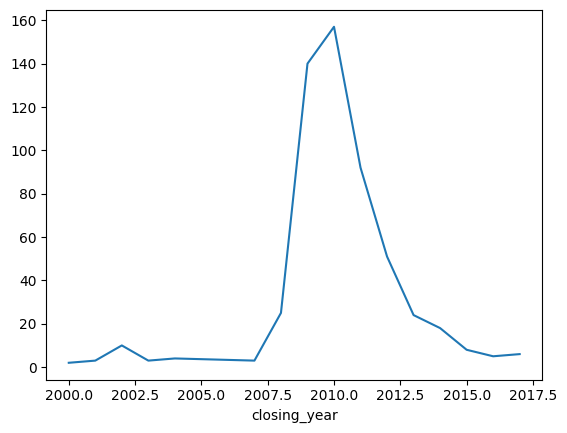

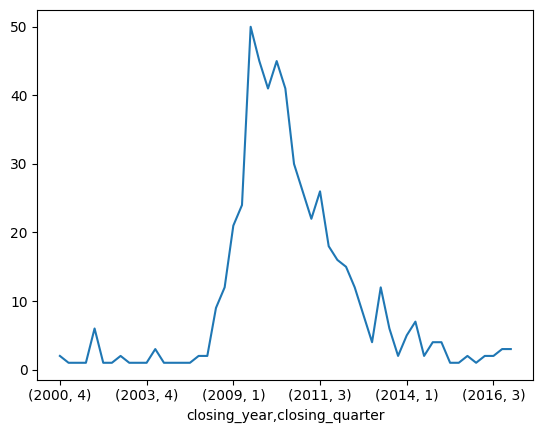

In [54]:
# 위의 값 그래프로
import matplotlib.pyplot as plt
fig, ax = plt. subplots()
ax = closing_year.plot()
plt.show()

fig ,ax = plt.subplots()
ax = closing_year_q.plot()
plt.show()

### 테슬라 주식 데이터로 시간 계산하기
 - pandas -datareaer 라이브러리 이용

In [55]:
pip install pandas-datareader

In [56]:
# 데이터 불러오기
pd.core.common.is_list_like = pd.api.types.is_list_like
import pandas_datareader as pdr

# tesla=pdr.get_data_quandl('TSLA', api_key = '받은 key')
# tesla.to_csv('../data/tesla_stock_quandl.csv')

tesla = pd.read_csv('/content/tesla_stock_quandl.csv')

In [57]:
# Date 열은 문자열 -> datetime 오브젝트로 변환
print(tesla.head())

         Date    Open    High     Low   Close      Volume  ExDividend  \
0  2018-03-27  304.00  304.27  277.18  279.18  13696168.0         0.0   
1  2018-03-26  307.34  307.59  291.36  304.18   8324639.0         0.0   
2  2018-03-23  311.25  311.61  300.45  301.54   6600538.0         0.0   
3  2018-03-22  313.89  318.82  308.18  309.10   4914307.0         0.0   
4  2018-03-21  310.25  322.44  310.19  316.53   5927881.0         0.0   

   SplitRatio  AdjOpen  AdjHigh  AdjLow  AdjClose   AdjVolume  
0         1.0   304.00   304.27  277.18    279.18  13696168.0  
1         1.0   307.34   307.59  291.36    304.18   8324639.0  
2         1.0   311.25   311.61  300.45    301.54   6600538.0  
3         1.0   313.89   318.82  308.18    309.10   4914307.0  
4         1.0   310.25   322.44  310.19    316.53   5927881.0  


In [58]:
# parse_dates 인자에 Date 열 전달 : datetime으로 형변환
tesla = pd.read_csv('/content/tesla_stock_quandl.csv',parse_dates=[0])
print(tesla.info)

<bound method DataFrame.info of            Date    Open      High     Low   Close      Volume  ExDividend  \
0    2018-03-27  304.00  304.2700  277.18  279.18  13696168.0         0.0   
1    2018-03-26  307.34  307.5900  291.36  304.18   8324639.0         0.0   
2    2018-03-23  311.25  311.6100  300.45  301.54   6600538.0         0.0   
3    2018-03-22  313.89  318.8200  308.18  309.10   4914307.0         0.0   
4    2018-03-21  310.25  322.4400  310.19  316.53   5927881.0         0.0   
...         ...     ...       ...     ...     ...         ...         ...   
1944 2010-07-06   20.00   20.0000   15.83   16.11   6866900.0         0.0   
1945 2010-07-02   23.00   23.1000   18.71   19.20   5139800.0         0.0   
1946 2010-07-01   25.00   25.9200   20.27   21.96   8218800.0         0.0   
1947 2010-06-30   25.79   30.4192   23.30   23.83  17187100.0         0.0   
1948 2010-06-29   19.00   25.0000   17.54   23.89  18766300.0         0.0   

      SplitRatio  AdjOpen   AdjHigh  AdjLow

In [59]:
# 불린으로 2010년 6월 데이터 추출
print(tesla.loc[(tesla.Date.dt.year == 2010)& (tesla.Date.dt.month == 6)])

           Date   Open     High    Low  Close      Volume  ExDividend  \
1947 2010-06-30  25.79  30.4192  23.30  23.83  17187100.0         0.0   
1948 2010-06-29  19.00  25.0000  17.54  23.89  18766300.0         0.0   

      SplitRatio  AdjOpen  AdjHigh  AdjLow  AdjClose   AdjVolume  
1947         1.0    25.79  30.4192   23.30     23.83  17187100.0  
1948         1.0    19.00  25.0000   17.54     23.89  18766300.0  


## DatetimeIndex
 datetime 오브젝트를 df의 인덱스로 설정하면 원하는 시간의 데이터를 바로 추출 가능

In [62]:
# Date 열을 tesla df 의 인덱스로 지정
tesla.index = tesla['Date']
print(tesla.index)

DatetimeIndex(['2018-03-27', '2018-03-26', '2018-03-23', '2018-03-22',
               '2018-03-21', '2018-03-20', '2018-03-19', '2018-03-16',
               '2018-03-15', '2018-03-14',
               ...
               '2010-07-13', '2010-07-12', '2010-07-09', '2010-07-08',
               '2010-07-07', '2010-07-06', '2010-07-02', '2010-07-01',
               '2010-06-30', '2010-06-29'],
              dtype='datetime64[ns]', name='Date', length=1949, freq=None)


In [64]:
# 2015 데이터 추출

print(tesla.loc['2015'].iloc[:5, :5])

                 Date    Open     High       Low   Close
Date                                                    
2015-12-31 2015-12-31  238.51  243.450  238.3700  240.01
2015-12-30 2015-12-30  236.60  243.634  235.6707  238.09
2015-12-29 2015-12-29  230.06  237.720  229.5470  237.19
2015-12-28 2015-12-28  231.49  231.980  225.5400  228.95
2015-12-24 2015-12-24  230.56  231.880  228.2800  230.57


In [66]:
# 2010년 6월 데이터 추출
print(tesla.loc['2010-06'].iloc[:,:5])

                 Date   Open     High    Low  Close
Date                                               
2010-06-30 2010-06-30  25.79  30.4192  23.30  23.83
2010-06-29 2010-06-29  19.00  25.0000  17.54  23.89


## TimedeltaIndex
시간 간격을 인덱스로 지정해 데이터를 추출하는 방법

In [67]:
# Date 열에서 Date 열의 최솟값을 빼고 ref_date로 추가
tesla['ref_date'] = tesla['Date'] - tesla['Date'].min()
print(tesla.head())

                 Date    Open    High     Low   Close      Volume  ExDividend  \
Date                                                                            
2018-03-27 2018-03-27  304.00  304.27  277.18  279.18  13696168.0         0.0   
2018-03-26 2018-03-26  307.34  307.59  291.36  304.18   8324639.0         0.0   
2018-03-23 2018-03-23  311.25  311.61  300.45  301.54   6600538.0         0.0   
2018-03-22 2018-03-22  313.89  318.82  308.18  309.10   4914307.0         0.0   
2018-03-21 2018-03-21  310.25  322.44  310.19  316.53   5927881.0         0.0   

            SplitRatio  AdjOpen  AdjHigh  AdjLow  AdjClose   AdjVolume  \
Date                                                                     
2018-03-27         1.0   304.00   304.27  277.18    279.18  13696168.0   
2018-03-26         1.0   307.34   307.59  291.36    304.18   8324639.0   
2018-03-23         1.0   311.25   311.61  300.45    301.54   6600538.0   
2018-03-22         1.0   313.89   318.82  308.18    309.10   4

In [68]:
# ref_date 인덱스로 지정, 시간 간격을 이용해 데이터 추출
tesla.index = tesla['ref_date']
print(tesla.iloc[:5,:5])

                Date    Open    High     Low   Close
ref_date                                            
2828 days 2018-03-27  304.00  304.27  277.18  279.18
2827 days 2018-03-26  307.34  307.59  291.36  304.18
2824 days 2018-03-23  311.25  311.61  300.45  301.54
2823 days 2018-03-22  313.89  318.82  308.18  309.10
2822 days 2018-03-21  310.25  322.44  310.19  316.53


In [70]:
# 데이터 수집 이후 최초 5일 데이터 추출
print(tesla['5 days':].iloc[:5,:5])

               Date   Open     High    Low  Close
ref_date                                         
3 days   2010-07-02  23.00  23.1000  18.71  19.20
2 days   2010-07-01  25.00  25.9200  20.27  21.96
1 days   2010-06-30  25.79  30.4192  23.30  23.83
0 days   2010-06-29  19.00  25.0000  17.54  23.89


## 시간 범위와 인덱스
특정 일에 누락된 데이터도 포함시켜 데이터를 살펴보려면 임의로 시간 범위를 생성하여 인덱스로 지정

In [71]:
ebola = pd.read_csv('/content/country_timeseries.csv', parse_dates=[0])
print(ebola.iloc[:5,:5])

        Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
0 2015-01-05  289        2776.0            NaN            10030.0
1 2015-01-04  288        2775.0            NaN             9780.0
2 2015-01-03  287        2769.0         8166.0             9722.0
3 2015-01-02  286           NaN         8157.0                NaN
4 2014-12-31  284        2730.0         8115.0             9633.0


In [72]:
#2014년 3월 23일 데이터 누락
print(ebola.iloc[-5:,:5])

          Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
117 2014-03-27    5         103.0            8.0                6.0
118 2014-03-26    4          86.0            NaN                NaN
119 2014-03-25    3          86.0            NaN                NaN
120 2014-03-24    2          86.0            NaN                NaN
121 2014-03-22    0          49.0            NaN                NaN


In [73]:
# date_range 이용하여 시간 인덱스 생성
head_range = pd.date_range(start ='2014-12-31',end='2015-01-05')
print(head_range)

DatetimeIndex(['2014-12-31', '2015-01-01', '2015-01-02', '2015-01-03',
               '2015-01-04', '2015-01-05'],
              dtype='datetime64[ns]', freq='D')


In [74]:
# ebola df의 앞쪽 5개 데이터 추출 후 새로운 df 생성
ebola_5 = ebola.head()
ebola_5.indes = ebola_5['Date']
ebola_5.reindex(head_range)
print(ebola_5.iloc[:5,:5])

        Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
0 2015-01-05  289        2776.0            NaN            10030.0
1 2015-01-04  288        2775.0            NaN             9780.0
2 2015-01-03  287        2769.0         8166.0             9722.0
3 2015-01-02  286           NaN         8157.0                NaN
4 2014-12-31  284        2730.0         8115.0             9633.0


/tmp/ipykernel_5623/533273719.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  ebola_5.indes = ebola_5['Date']


In [77]:
# 시간 범위의 주기 설정
print(pd.date_range('2017-01-01', '2017-01-07', freq='B'))

DatetimeIndex(['2017-01-02', '2017-01-03', '2017-01-04', '2017-01-05',
               '2017-01-06'],
              dtype='datetime64[ns]', freq='B')


## shift 메서드
나라별로 확산 속도를 비교하려면 발생하기 시작한 날짜를 옮기는 것이 좋음

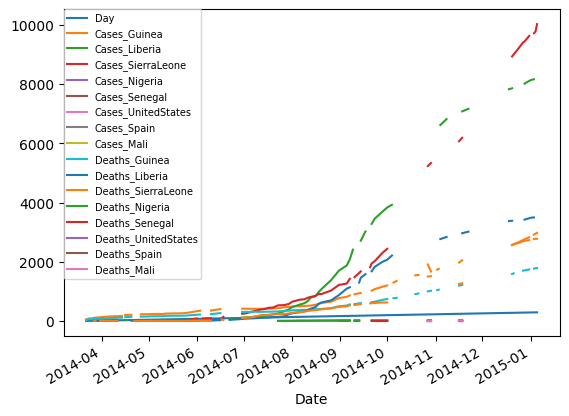

In [78]:
# Date를 인덱스로, x축 : Date, y축 : 사망자수
import matplotlib.pyplot as plt

ebola.index = ebola['Date']
fig , ax = plt.subplots()
ax = ebola.iloc[0:,1:].plot(ax=ax)
ax.legend(fontsize = 7, loc =2, borderaxespad = 0.)
plt.show()

In [79]:
# 각 나라의 발병일을 가장 처음 에볼라가 발병한 guinea와 동일한 위치로 옮김
ebola_sub = ebola[['Day','Cases_Guinea','Cases_Liberia']]
print(ebola_sub.tail(10))

            Day  Cases_Guinea  Cases_Liberia
Date                                        
2014-04-04   13         143.0           18.0
2014-04-01   10         127.0            8.0
2014-03-31    9         122.0            8.0
2014-03-29    7         112.0            7.0
2014-03-28    6         112.0            3.0
2014-03-27    5         103.0            8.0
2014-03-26    4          86.0            NaN
2014-03-25    3          86.0            NaN
2014-03-24    2          86.0            NaN
2014-03-22    0          49.0            NaN


In [80]:
# df 준비
# 시간 범위의 주기 설정
ebola = pd.read_csv('/content/country_timeseries.csv', parse_dates=['Date'])
print(ebola.head( ).iloc[:, :5])

        Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
0 2015-01-05  289        2776.0            NaN            10030.0
1 2015-01-04  288        2775.0            NaN             9780.0
2 2015-01-03  287        2769.0         8166.0             9722.0
3 2015-01-02  286           NaN         8157.0                NaN
4 2014-12-31  284        2730.0         8115.0             9633.0


In [81]:
print(ebola.tail().iloc[:,:5])

          Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
117 2014-03-27    5         103.0            8.0                6.0
118 2014-03-26    4          86.0            NaN                NaN
119 2014-03-25    3          86.0            NaN                NaN
120 2014-03-24    2          86.0            NaN                NaN
121 2014-03-22    0          49.0            NaN                NaN


In [83]:
# 날짜가 x 데이터의 인덱스 생성
ebola.index = ebola['Date']
new_idx = pd.date_range(ebola.index.min( ), ebola.index.max( ))

In [84]:
# reversed를 이용해 시간 순서 맞추기
print(new_idx)

DatetimeIndex(['2014-03-22', '2014-03-23', '2014-03-24', '2014-03-25',
               '2014-03-26', '2014-03-27', '2014-03-28', '2014-03-29',
               '2014-03-30', '2014-03-31',
               ...
               '2014-12-27', '2014-12-28', '2014-12-29', '2014-12-30',
               '2014-12-31', '2015-01-01', '2015-01-02', '2015-01-03',
               '2015-01-04', '2015-01-05'],
              dtype='datetime64[ns]', length=290, freq='D')


In [85]:
new_idx = reversed(new_idx)

In [86]:
# reindex 이용해 new_idx를 새로운 인덱스로 지정
ebola = ebola.reindex(new_idx)
print(ebola.head().iloc[:,:5])

                 Date    Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
Date                                                                        
2015-01-05 2015-01-05  289.0        2776.0            NaN            10030.0
2015-01-04 2015-01-04  288.0        2775.0            NaN             9780.0
2015-01-03 2015-01-03  287.0        2769.0         8166.0             9722.0
2015-01-02 2015-01-02  286.0           NaN         8157.0                NaN
2015-01-01        NaT    NaN           NaN            NaN                NaN


In [87]:
print(ebola.tail().iloc[:,:5])

                 Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
Date                                                                      
2014-03-26 2014-03-26  4.0          86.0            NaN                NaN
2014-03-25 2014-03-25  3.0          86.0            NaN                NaN
2014-03-24 2014-03-24  2.0          86.0            NaN                NaN
2014-03-23        NaT  NaN           NaN            NaN                NaN
2014-03-22 2014-03-22  0.0          49.0            NaN                NaN


In [88]:
# 각 나라의 에볼라 발병일 옮기기
last_valid = ebola.apply(pd.Series.last_valid_index)
print(last_valid)

Date                  2014-03-22
Day                   2014-03-22
Cases_Guinea          2014-03-22
Cases_Liberia         2014-03-27
Cases_SierraLeone     2014-03-27
Cases_Nigeria         2014-07-23
Cases_Senegal         2014-08-31
Cases_UnitedStates    2014-10-01
Cases_Spain           2014-10-08
Cases_Mali            2014-10-22
Deaths_Guinea         2014-03-22
Deaths_Liberia        2014-03-27
Deaths_SierraLeone    2014-03-27
Deaths_Nigeria        2014-07-23
Deaths_Senegal        2014-09-07
Deaths_UnitedStates   2014-10-01
Deaths_Spain          2014-10-08
Deaths_Mali           2014-10-22
dtype: datetime64[ns]


In [89]:
first_valid = ebola.apply(pd.Series.first_valid_index)
print(first_valid)

Date                  2015-01-05
Day                   2015-01-05
Cases_Guinea          2015-01-05
Cases_Liberia         2015-01-03
Cases_SierraLeone     2015-01-05
Cases_Nigeria         2014-12-07
Cases_Senegal         2014-12-07
Cases_UnitedStates    2014-12-07
Cases_Spain           2014-12-07
Cases_Mali            2014-12-07
Deaths_Guinea         2015-01-05
Deaths_Liberia        2015-01-03
Deaths_SierraLeone    2015-01-05
Deaths_Nigeria        2014-12-07
Deaths_Senegal        2014-12-07
Deaths_UnitedStates   2014-12-07
Deaths_Spain          2014-12-07
Deaths_Mali           2014-12-07
dtype: datetime64[ns]


In [90]:
# 에볼라 처음 발병한 날 - 각 나라의 에볼라 발병일 만큼 옮기면 됨
earliest_date = ebola.index.min( )
print(earliest_date)

2014-03-22 00:00:00


In [91]:
shift_values = last_valid - earliest_date
print(shift_values)

Date                    0 days
Day                     0 days
Cases_Guinea            0 days
Cases_Liberia           5 days
Cases_SierraLeone       5 days
Cases_Nigeria         123 days
Cases_Senegal         162 days
Cases_UnitedStates    193 days
Cases_Spain           200 days
Cases_Mali            214 days
Deaths_Guinea           0 days
Deaths_Liberia          5 days
Deaths_SierraLeone      5 days
Deaths_Nigeria        123 days
Deaths_Senegal        169 days
Deaths_UnitedStates   193 days
Deaths_Spain          200 days
Deaths_Mali           214 days
dtype: timedelta64[ns]


In [93]:
# 각 나라의 에볼라 발병일 변경
ebola_dict = {}
for idx, col in enumerate(ebola):
  d = shift_values[idx].days
  shifted = ebola[col].shift(d)
  ebola_dict[col] = shifted

/tmp/ipykernel_5623/93444575.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  d = shift_values[idx].days


In [95]:
# df 메서드 이용해 ebola_dict 값 df 로 변환
ebola_shift = pd.DataFrame(ebola_dict)

In [96]:
print(ebola_shift.tail())

                 Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone  \
Date                                                                         
2014-03-26 2014-03-26  4.0          86.0            8.0                2.0   
2014-03-25 2014-03-25  3.0          86.0            NaN                NaN   
2014-03-24 2014-03-24  2.0          86.0            7.0                NaN   
2014-03-23        NaT  NaN           NaN            3.0                2.0   
2014-03-22 2014-03-22  0.0          49.0            8.0                6.0   

            Cases_Nigeria  Cases_Senegal  Cases_UnitedStates  Cases_Spain  \
Date                                                                        
2014-03-26            1.0            NaN                 1.0          1.0   
2014-03-25            NaN            NaN                 NaN          NaN   
2014-03-24            NaN            NaN                 NaN          NaN   
2014-03-23            NaN            NaN                 NaN        

In [97]:
# 인덱스를 Day로 지정, 필요하지 않은 Date, Day 삭제
ebola_shift.index = ebola_shift['Day']
ebola_shift = ebola_shift.drop(['Date', 'Day'], axis=1)
print(ebola_shift.tail( ))

     Cases_Guinea  Cases_Liberia  Cases_SierraLeone  Cases_Nigeria  \
Day                                                                  
4.0          86.0            8.0                2.0            1.0   
3.0          86.0            NaN                NaN            NaN   
2.0          86.0            7.0                NaN            NaN   
NaN           NaN            3.0                2.0            NaN   
0.0          49.0            8.0                6.0            0.0   

     Cases_Senegal  Cases_UnitedStates  Cases_Spain  Cases_Mali  \
Day                                                               
4.0            NaN                 1.0          1.0         NaN   
3.0            NaN                 NaN          NaN         NaN   
2.0            NaN                 NaN          NaN         NaN   
NaN            NaN                 NaN          NaN         NaN   
0.0            1.0                 1.0          1.0         1.0   

     Deaths_Guinea  Deaths_Liberia  Dea

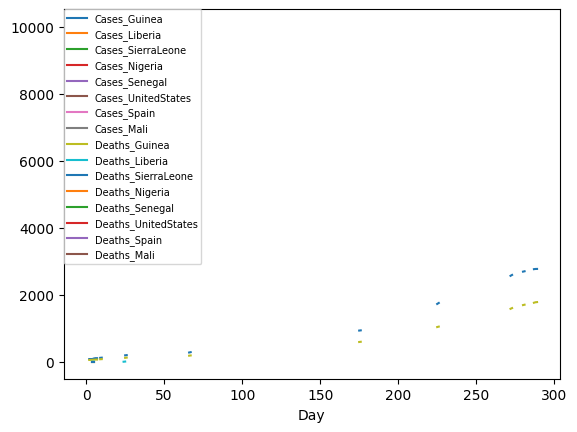

In [99]:
fig, ax = plt.subplots( )
ax = ebola_shift.iloc[:, :].plot(ax=ax)
ax.legend(fontsize=7, loc=2, borderaxespad=0.)
plt.show( )